In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

In [ ]:
pd.set_option('display.float_format', lambda x: '%.3f' % x)

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Machine Learning/Projects/Real Estate Capstone Project/DataSets/Outliers Removed/Outliers_removed_real_estate.csv')
df_copy = df.copy()
df.head()

,bhk,price,age_of_property,which_floor,project_name,bedrooms,bathrooms,balcony,parking,source,location,buildup_area_sqft,carpet_area_sqft,is_ready_to_move,furnishing,price_per_sqft,property_score,locationadvantages,topfacilities,age_category,log_price
0,3.000,2.050,15.000,Middle,Moroccan Cooperative,3.000,3.000,3.000,1.000,kaggle,Goregaon East,1862.000,1425.000,True,Semi Furnished,11009.667,4,NaN,NaN,Mid Age,1.115
1,1.000,1.330,1.000,Lower,Rajesh White City,1.000,2.000,0.000,1.000,kaggle,Kandivali East,790.000,479.000,True,Unfurnished,16835.443,1,NaN,NaN,New,0.846
2,3.000,7.300,10.000,Lower,Oberoi Esquire,3.000,2.000,0.000,2.000,kaggle,Goregaon East,1430.000,1330.000,True,Unfurnished,51048.951,3,NaN,NaN,Mid Age,2.116
3,3.000,7.600,4.000,Higher,Oberoi Esquire,3.000,4.000,0.000,3.000,kaggle,Goregaon East,2195.000,1400.000,True,Semi Furnished,34624.146,5,NaN,NaN,Relatively New,2.152
4,2.000,3.200,3.000,Lower,Ajmera Zeon,2.000,2.000,1.000,1.000,kaggle,Wadala East,960.000,860.000,True,Unfurnished,33333.333,3,NaN,NaN,Relatively New,1.435


In [ ]:
display(df.head())

,bhk,price,age_of_property,which_floor,project_name,bedrooms,bathrooms,balcony,parking,source,location,buildup_area_sqft,carpet_area_sqft,is_ready_to_move,furnishing,price_per_sqft,property_score,locationadvantages,topfacilities,age_category,log_price
0,3.000,2.050,15.000,Middle,Moroccan Cooperative,3.000,3.000,3.000,1.000,kaggle,Goregaon East,1862.000,1425.000,True,Semi Furnished,11009.667,4,NaN,NaN,Mid Age,1.115
1,1.000,1.330,1.000,Lower,Rajesh White City,1.000,2.000,0.000,1.000,kaggle,Kandivali East,790.000,479.000,True,Unfurnished,16835.443,1,NaN,NaN,New,0.846
2,3.000,7.300,10.000,Lower,Oberoi Esquire,3.000,2.000,0.000,2.000,kaggle,Goregaon East,1430.000,1330.000,True,Unfurnished,51048.951,3,NaN,NaN,Mid Age,2.116
3,3.000,7.600,4.000,Higher,Oberoi Esquire,3.000,4.000,0.000,3.000,kaggle,Goregaon East,2195.000,1400.000,True,Semi Furnished,34624.146,5,NaN,NaN,Relatively New,2.152
4,2.000,3.200,3.000,Lower,Ajmera Zeon,2.000,2.000,1.000,1.000,kaggle,Wadala East,960.000,860.000,True,Unfurnished,33333.333,3,NaN,NaN,Relatively New,1.435


In [ ]:
df.drop(columns=['age_of_property', 'locationadvantages', 'topfacilities'], inplace=True)

<Axes: >

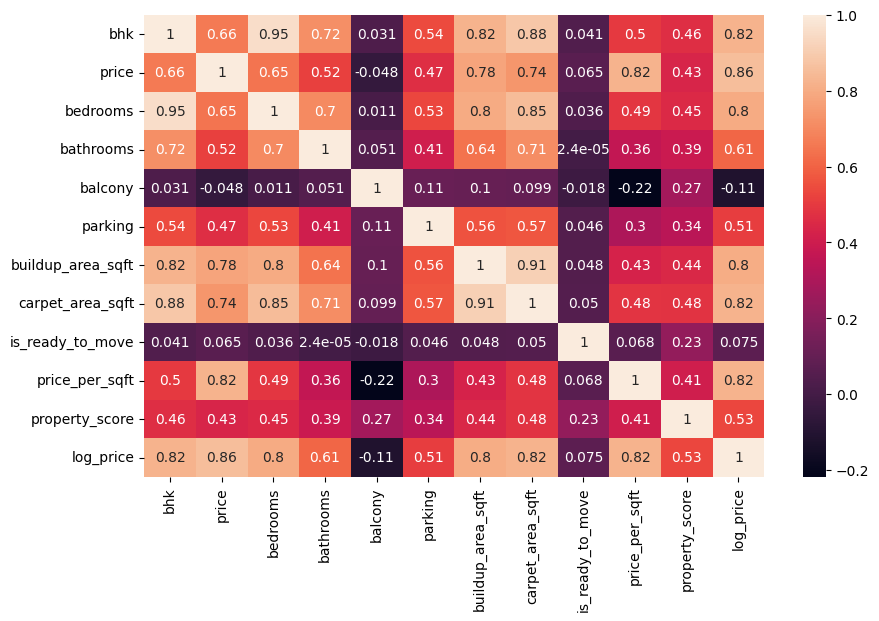

In [ ]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot = True)

In [ ]:
df.columns

Index(['bhk', 'price', 'which_floor', 'project_name', 'bedrooms', 'bathrooms',
       'balcony', 'parking', 'source', 'location', 'buildup_area_sqft',
       'carpet_area_sqft', 'is_ready_to_move', 'furnishing', 'price_per_sqft',
       'property_score', 'age_category', 'log_price'],
      dtype='object')

In [ ]:
df.drop(
columns= [
    'log_price',
    'price_per_sqft',
    'carpet_area_sqft',
    'bedrooms',
    'project_name',
    'source',
],
inplace = True
)

In [ ]:
df.head()

,bhk,price,which_floor,bathrooms,balcony,parking,location,buildup_area_sqft,is_ready_to_move,furnishing,property_score,age_category
0,3.000,2.050,Middle,3.000,3.000,1.000,Goregaon East,1862.000,True,Semi Furnished,4,Mid Age
1,1.000,1.330,Lower,2.000,0.000,1.000,Kandivali East,790.000,True,Unfurnished,1,New
2,3.000,7.300,Lower,2.000,0.000,2.000,Goregaon East,1430.000,True,Unfurnished,3,Mid Age
3,3.000,7.600,Higher,4.000,0.000,3.000,Goregaon East,2195.000,True,Semi Furnished,5,Relatively New
4,2.000,3.200,Lower,2.000,1.000,1.000,Wadala East,960.000,True,Unfurnished,3,Relatively New


In [ ]:
df['furnishing'].unique()

array(['Semi Furnished', 'Unfurnished', 'Unknown', 'Fully Furnished'],
      dtype=object)

In [ ]:
print(df['furnishing'].value_counts(normalize=True) * 100)

furnishing
Semi Furnished    33.220
Unknown           28.607
Unfurnished       28.468
Fully Furnished    9.705
Name: proportion, dtype: float64


- Keeping `unknown` as a category since it takes 29% of the data

In [ ]:
df['location'].nunique()

136

In [ ]:
with pd.option_context("display.max_rows", None):
  display(df.groupby('location')['price'].mean().sort_index())

,price
location,
Agripada,4.242
Andheri,3.470
Andheri East,2.425
Andheri West,4.823
Antop Hill,1.630
Anushakti Nagar,3.617
Asalpha,0.670
Bandra,4.901
Bandra East,6.591


In [ ]:
zone_map = {
    # South Mumbai (premium)
    'Worli': 'South Mumbai', 'Prabhadevi': 'South Mumbai',
    'Lower Parel': 'South Mumbai', 'Mahalaxmi': 'South Mumbai',
    'Tardeo': 'South Mumbai', 'Colaba': 'South Mumbai',
    'Cuffe Parade': 'South Mumbai', 'Marine Lines': 'South Mumbai',
    'Churchgate': 'South Mumbai', 'Malabar Hill': 'South Mumbai',
    'Grant Road': 'South Mumbai', 'Byculla': 'South Mumbai',
    'Matunga': 'South Mumbai', 'Dadar East': 'South Mumbai',
    'Dadar West': 'South Mumbai', 'Parel': 'South Mumbai',
    'Agripada': 'South Mumbai', 'Antop Hill': 'South Mumbai',
    'Bhuleshwar': 'South Mumbai', 'Byculla East': 'South Mumbai',
    'Chinchpokli': 'South Mumbai', 'Cumballa Hill': 'South Mumbai',
    'Fort': 'South Mumbai', 'Gamdevi': 'South Mumbai',
    'Girgaon': 'South Mumbai', 'Jacob Circle': 'South Mumbai',
    'Kalbadevi': 'South Mumbai', 'Kamathipura': 'South Mumbai',
    'Madanpura': 'South Mumbai', 'Mahalakshmi': 'South Mumbai',
    'Matunga East': 'South Mumbai', 'Matunga West': 'South Mumbai',
    'Mazgaon': 'South Mumbai', 'Mumbai Central': 'South Mumbai',
    'Mumbai South': 'South Mumbai', 'Nagpada': 'South Mumbai',
    'Parel East': 'South Mumbai', 'Sewri': 'South Mumbai',
    'Umerkhadi': 'South Mumbai', 'Wadala': 'South Mumbai',
    'Wadala East': 'South Mumbai', 'Worli Seaface': 'South Mumbai',
    'Lower Parel West': 'South Mumbai',

    # Western Suburbs (mid-premium)
    'Bandra': 'Western Suburbs', 'Bandra West': 'Western Suburbs',
    'Bandra East': 'Western Suburbs', 'Khar': 'Western Suburbs',
    'Santacruz West': 'Western Suburbs', 'Juhu': 'Western Suburbs',
    'Vile Parle': 'Western Suburbs', 'Andheri West': 'Western Suburbs',
    'Jogeshwari West': 'Western Suburbs', 'Goregaon West': 'Western Suburbs',
    'Malad West': 'Western Suburbs', 'Kandivali West': 'Western Suburbs',
    'Borivali West': 'Western Suburbs', 'Dahisar West': 'Western Suburbs',
    'Andheri': 'Western Suburbs', 'Borivali': 'Western Suburbs',
    'Dahisar': 'Western Suburbs', 'Jogeshwari': 'Western Suburbs',
    'Khar East': 'Western Suburbs', 'Khar West': 'Western Suburbs',
    'Lokhandwala Andheri West': 'Western Suburbs',
    'Madh': 'Western Suburbs', 'Mahim': 'Western Suburbs',
    'Mahim West': 'Western Suburbs', 'Malad': 'Western Suburbs',
    'Vile Parle East': 'Western Suburbs',
    'Vile Parle West': 'Western Suburbs',

    # Western Suburbs East (mid)
    'Andheri East': 'Western Suburbs East', 'Jogeshwari East': 'Western Suburbs East',
    'Goregaon East': 'Western Suburbs East', 'Malad East': 'Western Suburbs East',
    'Kandivali East': 'Western Suburbs East', 'Borivali East': 'Western Suburbs East',
    'Dahisar East': 'Western Suburbs East', 'Powai': 'Western Suburbs East',
    'Chandivali': 'Western Suburbs East',
    'Dharamveer Nagar': 'Western Suburbs East',
    'Goregaon': 'Western Suburbs East',
    'Hiranandani Gardens Powai': 'Western Suburbs East',
    'Marol': 'Western Suburbs East',
    'Sakinaka': 'Western Suburbs East',
    'Santacruz East': 'Western Suburbs East',

    # Eastern Suburbs (affordable)
    'Ghatkopar East': 'Eastern Suburbs', 'Ghatkopar West': 'Eastern Suburbs',
    'Vikhroli East': 'Eastern Suburbs', 'Vikhroli West': 'Eastern Suburbs',
    'Kanjurmarg East': 'Eastern Suburbs', 'Kanjurmarg West': 'Eastern Suburbs',
    'Bhandup East': 'Eastern Suburbs', 'Bhandup West': 'Eastern Suburbs',
    'Mulund East': 'Eastern Suburbs', 'Mulund West': 'Eastern Suburbs',
    'Chembur': 'Eastern Suburbs', 'Chembur East': 'Eastern Suburbs',
    'Kurla East': 'Eastern Suburbs', 'Kurla West': 'Eastern Suburbs',
    'Anushakti Nagar': 'Eastern Suburbs', 'Asalpha': 'Eastern Suburbs',
    'Bhandup': 'Eastern Suburbs', 'Chembur West': 'Eastern Suburbs',
    'Ghatkopar': 'Eastern Suburbs', 'Govandi': 'Eastern Suburbs',
    'Hariyali': 'Eastern Suburbs', 'Kanjurmarg': 'Eastern Suburbs',
    'Lbs Marg': 'Eastern Suburbs', 'Mankhurd': 'Eastern Suburbs',
    'Mulund': 'Eastern Suburbs', 'Ramabai Ambedkar Nagar': 'Eastern Suburbs',
    'Sion': 'Eastern Suburbs', 'Sion East': 'Eastern Suburbs',
    'Sion West': 'Eastern Suburbs', 'Trombay': 'Eastern Suburbs',
    'Vidyavihar': 'Eastern Suburbs', 'Vikhroli': 'Eastern Suburbs',

    # Navi Mumbai / Thane (budget)
    'Thane West': 'Thane Navi Mumbai', 'Mira Road East': 'Thane Navi Mumbai',
    'Mira Road West': 'Thane Navi Mumbai', 'Bhayandar East': 'Thane Navi Mumbai',
    'Bhayandar West': 'Thane Navi Mumbai',
    'Ghodbander': 'Thane Navi Mumbai',

    # Outskirts (very budget)
    'Naigaon East': 'Outskirts', 'Naigaon West': 'Outskirts',
    'Nalasopara East': 'Outskirts', 'Nalasopara West': 'Outskirts',
    'Virar East': 'Outskirts', 'Virar West': 'Outskirts',
    'Vasai East': 'Outskirts', 'Vasai West': 'Outskirts',
    'Palghar': 'Outskirts', 'Boisar': 'Outskirts',
    'Saphale': 'Outskirts', 'Uttan': 'Outskirts',
    'Makane Kapase': 'Outskirts',
}

df['location_zone'] = df['location'].map(zone_map).fillna('Other')
print(df['location_zone'].value_counts())

location_zone
Western Suburbs         2613
Eastern Suburbs         2343
Western Suburbs East    2067
South Mumbai            1139
Thane Navi Mumbai        990
Outskirts                884
Name: count, dtype: int64


In [ ]:
df.drop('location', axis=1, inplace=True)

In [ ]:
df['property_score'].value_counts()

,count
property_score,
2,2598
1,2266
3,2240
0,1166
4,924
5,567
6,237
7,38


In [ ]:
df.drop(columns=['property_score'], inplace=True)

In [ ]:
df['which_floor'].value_counts(normalize=True)*100

,proportion
which_floor,
Middle,35.931
Higher,26.126
Lower,19.749
Unknown,18.194


In [ ]:
df.head()

,bhk,price,which_floor,bathrooms,balcony,parking,buildup_area_sqft,is_ready_to_move,furnishing,age_category,location_zone
0,3.000,2.050,Middle,3.000,3.000,1.000,1862.000,True,Semi Furnished,Mid Age,Western Suburbs East
1,1.000,1.330,Lower,2.000,0.000,1.000,790.000,True,Unfurnished,New,Western Suburbs East
2,3.000,7.300,Lower,2.000,0.000,2.000,1430.000,True,Unfurnished,Mid Age,Western Suburbs East
3,3.000,7.600,Higher,4.000,0.000,3.000,2195.000,True,Semi Furnished,Relatively New,Western Suburbs East
4,2.000,3.200,Lower,2.000,1.000,1.000,960.000,True,Unfurnished,Relatively New,South Mumbai


In [ ]:
df['is_ready_to_move'].value_counts(normalize=True)*100

,proportion
is_ready_to_move,
True,91.959
False,8.041


In [ ]:
df['is_ready_to_move'] = df['is_ready_to_move'].astype(int)

In [ ]:
df.head()

,bhk,price,which_floor,bathrooms,balcony,parking,buildup_area_sqft,is_ready_to_move,furnishing,age_category,location_zone
0,3.000,2.050,Middle,3.000,3.000,1.000,1862.000,1,Semi Furnished,Mid Age,Western Suburbs East
1,1.000,1.330,Lower,2.000,0.000,1.000,790.000,1,Unfurnished,New,Western Suburbs East
2,3.000,7.300,Lower,2.000,0.000,2.000,1430.000,1,Unfurnished,Mid Age,Western Suburbs East
3,3.000,7.600,Higher,4.000,0.000,3.000,2195.000,1,Semi Furnished,Relatively New,Western Suburbs East
4,2.000,3.200,Lower,2.000,1.000,1.000,960.000,1,Unfurnished,Relatively New,South Mumbai


In [ ]:
df.to_csv("ready_to_train_real_estate.csv", index=False)

In [ ]:
from sklearn.preprocessing import OneHotEncoder

cat_cols = ['which_floor', 'furnishing', 'age_category', 'location_zone']

ohe = OneHotEncoder(drop='first', sparse_output=False)
ohe_transformed = ohe.fit_transform(df[cat_cols])

ohe_df = pd.DataFrame(ohe_transformed, columns=ohe.get_feature_names_out(cat_cols))


df.reset_index(drop=True, inplace=True)
df = pd.concat([df.drop(columns=cat_cols), ohe_df], axis=1)

display(df.head())

,bhk,price,bathrooms,balcony,parking,buildup_area_sqft,is_ready_to_move,which_floor_Lower,which_floor_Middle,which_floor_Unknown,furnishing_Semi Furnished,furnishing_Unfurnished,furnishing_Unknown,age_category_New,age_category_Old,age_category_Relatively New,location_zone_Outskirts,location_zone_South Mumbai,location_zone_Thane Navi Mumbai,location_zone_Western Suburbs,location_zone_Western Suburbs East
0,3.000,2.050,3.000,3.000,1.000,1862.000,1,0.000,1.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000
1,1.000,1.330,2.000,0.000,1.000,790.000,1,1.000,0.000,0.000,0.000,1.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000
2,3.000,7.300,2.000,0.000,2.000,1430.000,1,1.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000
3,3.000,7.600,4.000,0.000,3.000,2195.000,1,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000
4,2.000,3.200,2.000,1.000,1.000,960.000,1,1.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,1.000,0.000,1.000,0.000,0.000,0.000


In [ ]:
X_label = df.drop('price', axis=1)
y_label = df['price']

## Feature Selection Techniques

1. Correlation Analysis  
2. Random Forest Feature Importance  
3. Gradient Boosting Feature Importances  
4. Permutation Importance  
5. LASSO  
6. Ridge  
7. Linear Regression Coefficients  
8. SHAP

### Correlation Analysis

<Axes: >

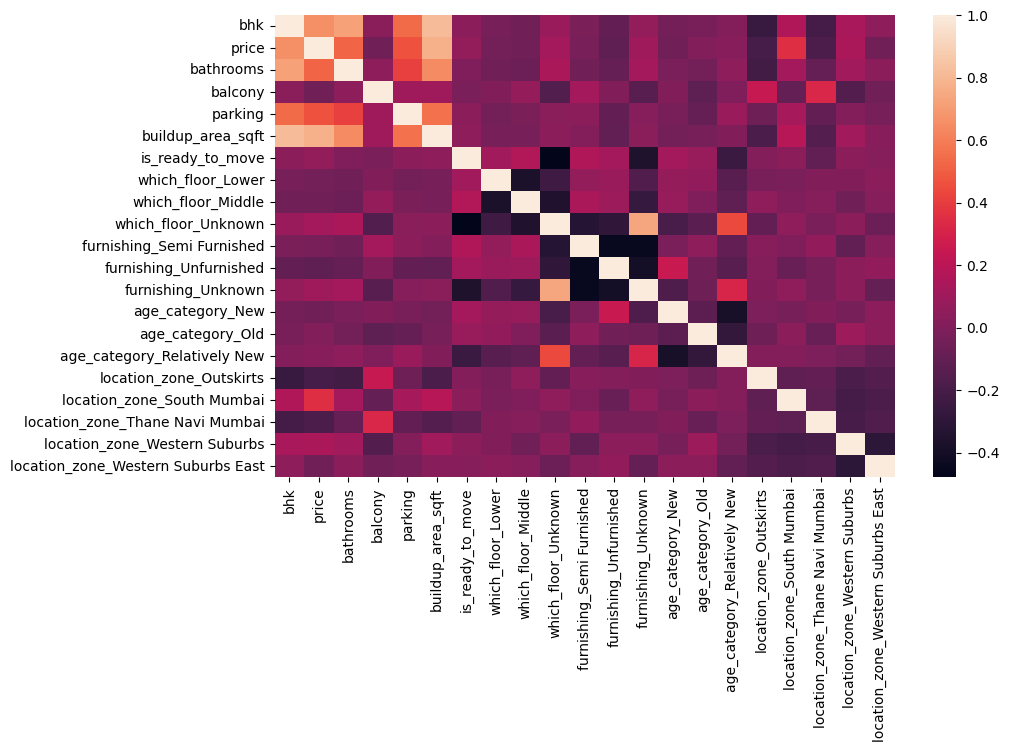

In [ ]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix)

In [ ]:
fi_df1 = corr_matrix.loc['price'].sort_values(ascending=False)
fi_df1

,price
price,1.000
buildup_area_sqft,0.780
bhk,0.658
bathrooms,0.519
parking,0.465
location_zone_South Mumbai,0.348
location_zone_Western Suburbs,0.141
which_floor_Unknown,0.122
furnishing_Unknown,0.104
is_ready_to_move,0.065


## Random Forest Feature Importance

In [ ]:
from sklearn.ensemble import RandomForestRegressor


rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_label, y_label)


fi_df2 = pd.DataFrame({
    'feature': X_label.columns,
    'rf_importance': rf_label.feature_importances_
}).sort_values(by='rf_importance', ascending=False)

In [ ]:
fi_df2

,feature,rf_importance
4,buildup_area_sqft,0.744
16,location_zone_South Mumbai,0.063
0,bhk,0.041
8,which_floor_Unknown,0.025
18,location_zone_Western Suburbs,0.021
3,parking,0.018
1,bathrooms,0.016
2,balcony,0.014
13,age_category_Old,0.007
15,location_zone_Outskirts,0.006


###  Gradient Boosting Feature importances

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gb_label = GradientBoostingRegressor()
gb_label.fit(X_label, y_label)

fi_df3 = pd.DataFrame({
    'feature': X_label.columns,
    'gb_importance': gb_label.feature_importances_
}).sort_values(by='gb_importance', ascending=False)

fi_df3

,feature,gb_importance
4,buildup_area_sqft,0.727
0,bhk,0.118
16,location_zone_South Mumbai,0.077
8,which_floor_Unknown,0.019
18,location_zone_Western Suburbs,0.016
2,balcony,0.011
15,location_zone_Outskirts,0.007
3,parking,0.006
1,bathrooms,0.005
19,location_zone_Western Suburbs East,0.005


### Permutation Importance

In [ ]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

X_train_label, X_test_label, y_train_label, y_test_label = train_test_split(X_label, y_label, test_size=0.2, random_state=42)

rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_train_label, y_train_label)

perm_importance = permutation_importance(rf_label, X_test_label, y_test_label, n_repeats=30, random_state=42)


fi_df4 = pd.DataFrame({
    'feature': X_label.columns,
    'permutation_importance': perm_importance.importances_mean
}).sort_values(by='permutation_importance', ascending=False)

fi_df4

,feature,permutation_importance
4,buildup_area_sqft,0.844
16,location_zone_South Mumbai,0.106
18,location_zone_Western Suburbs,0.041
0,bhk,0.020
8,which_floor_Unknown,0.014
15,location_zone_Outskirts,0.011
3,parking,0.008
17,location_zone_Thane Navi Mumbai,0.007
13,age_category_Old,0.006
19,location_zone_Western Suburbs East,0.003


In [ ]:
from sklearn.metrics import r2_score

y_pred = rf_label.predict(X_test_label)

print("Test R²:", r2_score(y_test_label, y_pred))

Test R²: 0.7208790224863032


### Lasso



> Lasso can be one of the important method here too since we didnt perform ordinal encoding therefore linear model wont get affected



In [ ]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_label)


lasso = Lasso(alpha=0.01, random_state=42)
lasso.fit(X_scaled, y_label)

fi_df5 = pd.DataFrame({
    'feature': X_label.columns,
    'lasso_coeff': np.abs(lasso.coef_)
}).sort_values(by='lasso_coeff', ascending=False)

fi_df5

,feature,lasso_coeff
4,buildup_area_sqft,3.050
16,location_zone_South Mumbai,0.913
8,which_floor_Unknown,0.368
18,location_zone_Western Suburbs,0.356
2,balcony,0.308
5,is_ready_to_move,0.252
3,parking,0.179
13,age_category_Old,0.069
11,furnishing_Unknown,0.049
15,location_zone_Outskirts,0.029


### RFE

In [ ]:
from sklearn.feature_selection import RFE

estimator = RandomForestRegressor()

selector_label = RFE(estimator, n_features_to_select=X_label.shape[1], step=1)
selector_label = selector_label.fit(X_label, y_label)

selected_features = X_label.columns[selector_label.support_]

selected_coefficients = selector_label.estimator_.feature_importances_



fi_df6 = pd.DataFrame({
    'feature': selected_features,
    'rfe_score': selected_coefficients
}).sort_values(by='rfe_score', ascending=False)

fi_df6


,feature,rfe_score
4,buildup_area_sqft,0.743
16,location_zone_South Mumbai,0.062
0,bhk,0.043
8,which_floor_Unknown,0.024
18,location_zone_Western Suburbs,0.021
3,parking,0.018
1,bathrooms,0.018
2,balcony,0.013
13,age_category_Old,0.006
15,location_zone_Outskirts,0.006


### RFE using Linear Regression

In [ ]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

# Standard practice: Use scaled data for linear RFE so coefficients are comparable
estimator = LinearRegression()

selector_label = RFE(estimator, n_features_to_select=X_label.shape[1], step=1)
selector_label = selector_label.fit(X_scaled, y_label)

selected_features = X_label.columns[selector_label.support_]

# Magnitude of coefficients represents importance in a linear context
selected_coefficients = np.abs(selector_label.estimator_.coef_)

fi_df7 = pd.DataFrame({
    'feature': selected_features,
    'rfe_lr_score': selected_coefficients
}).sort_values(by='rfe_lr_score', ascending=False)

display(fi_df7)

,feature,rfe_lr_score
4,buildup_area_sqft,3.076
16,location_zone_South Mumbai,0.923
8,which_floor_Unknown,0.381
18,location_zone_Western Suburbs,0.368
2,balcony,0.315
5,is_ready_to_move,0.269
3,parking,0.190
11,furnishing_Unknown,0.109
13,age_category_Old,0.088
9,furnishing_Semi Furnished,0.066


In [ ]:
lin_reg = LinearRegression()
lin_reg.fit(X_scaled, y_label)

fi_df8 = pd.DataFrame({
    'feature': X_label.columns,
    'reg_coeffs': lin_reg.coef_
}).sort_values(by='reg_coeffs', ascending=False)

fi_df8

,feature,reg_coeffs
4,buildup_area_sqft,3.076
16,location_zone_South Mumbai,0.923
8,which_floor_Unknown,0.381
18,location_zone_Western Suburbs,0.368
5,is_ready_to_move,0.269
3,parking,0.190
11,furnishing_Unknown,0.109
13,age_category_Old,0.088
9,furnishing_Semi Furnished,0.066
10,furnishing_Unfurnished,0.063


In [ ]:
import shap

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_label, y_label)

X_sample = X_label.sample(500, random_state=42)

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_sample)
shap_sum = np.abs(shap_values).mean(axis=0)

shap_values

array([[-0.47077025,  0.09905999,  0.01665694, ...,  0.0764637 ,
        -0.13410967, -0.00186896],
       [ 0.41472691, -0.19866581,  0.07442474, ...,  0.04472873,
         1.13046522, -0.02886448],
       [-0.35563783,  0.01507759,  0.00359804, ...,  0.04212287,
        -0.17245641, -0.00726216],
       ...,
       [ 0.0548667 ,  0.00154047,  0.01601121, ...,  0.04017809,
        -0.17094965, -0.01087213],
       [-0.51753183,  0.01640877,  0.02464457, ...,  0.08265629,
         0.27227179, -0.00478532],
       [-0.36881964,  0.09560549, -0.04518562, ...,  0.04318772,
        -0.18495311, -0.00710361]])

In [ ]:
fi_df9 = pd.DataFrame({
    'feature': X_label.columns,
    'SHAP_score': np.abs(shap_values).mean(axis=0)
}).sort_values(by='SHAP_score', ascending=False)

fi_df9

,feature,SHAP_score
4,buildup_area_sqft,1.987
16,location_zone_South Mumbai,0.482
0,bhk,0.378
18,location_zone_Western Suburbs,0.329
15,location_zone_Outskirts,0.179
17,location_zone_Thane Navi Mumbai,0.123
3,parking,0.112
8,which_floor_Unknown,0.088
2,balcony,0.065
1,bathrooms,0.056


In [ ]:
fi_df9.to_csv('shap_feature_importance.csv', index=False)
print('SHAP importance saved successfully.')

SHAP importance saved successfully.


### Consolidating Feature Importance

In [ ]:
final_fi_df = pd.DataFrame({'feature': X_label.columns})

# Mapping each method to its corresponding score column
# Note: For correlations and coefficients, we use absolute values for ranking magnitude
final_fi_df = final_fi_df.merge(fi_df1.abs().reset_index().rename(columns={'index': 'feature', 'price': 'corr_rank'}), on='feature')
final_fi_df = final_fi_df.merge(fi_df2.rename(columns={'rf_importance': 'rf_rank'}), on='feature')
final_fi_df = final_fi_df.merge(fi_df3.rename(columns={'gb_importance': 'gb_rank'}), on='feature')
final_fi_df = final_fi_df.merge(fi_df4.rename(columns={'permutation_importance': 'perm_rank'}), on='feature')
final_fi_df = final_fi_df.merge(fi_df5.rename(columns={'lasso_coeff': 'lasso_rank'}), on='feature')
final_fi_df = final_fi_df.merge(fi_df6.rename(columns={'rfe_score': 'rfe_rf_rank'}), on='feature')
final_fi_df = final_fi_df.merge(fi_df7.rename(columns={'rfe_lr_score': 'rfe_lr_rank'}), on='feature')
final_fi_df = final_fi_df.merge(fi_df9.rename(columns={'SHAP_score': 'shap_rank'}), on='feature')


rank_cols = []
for col in final_fi_df.columns[1:]:
    rank_name = col + '_val'
    final_fi_df[rank_name] = final_fi_df[col].rank(ascending=False)
    rank_cols.append(rank_name)

# Average Rank
final_fi_df['final_average_rank'] = final_fi_df[rank_cols].mean(axis=1)
final_fi_df = final_fi_df.sort_values('final_average_rank')


display(final_fi_df[['feature', 'final_average_rank'] + rank_cols])
display(final_fi_df[['feature', 'final_average_rank']].reset_index(drop=True))

,feature,final_average_rank,corr_rank_val,rf_rank_val,gb_rank_val,perm_rank_val,lasso_rank_val,rfe_rf_rank_val,rfe_lr_rank_val,shap_rank_val
4,buildup_area_sqft,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
16,location_zone_South Mumbai,2.500,5.000,2.000,3.000,2.000,2.000,2.000,2.000,2.000
18,location_zone_Western Suburbs,4.750,8.000,5.000,5.000,3.000,4.000,5.000,4.000,4.000
8,which_floor_Unknown,5.000,9.000,4.000,4.000,5.000,3.000,4.000,3.000,8.000
0,bhk,5.812,2.000,3.000,2.000,4.000,16.500,3.000,13.000,3.000
3,parking,6.500,4.000,6.000,8.000,7.000,7.000,6.000,7.000,7.000
15,location_zone_Outskirts,8.250,6.000,10.000,7.000,6.000,10.000,10.000,12.000,5.000
2,balcony,8.500,15.000,8.000,6.000,12.000,5.000,8.000,5.000,9.000
1,bathrooms,9.500,3.000,7.000,9.000,13.000,12.000,7.000,15.000,10.000
13,age_category_Old,11.250,20.000,9.000,12.000,9.000,8.000,9.000,9.000,14.000


,feature,final_average_rank
0,buildup_area_sqft,1.000
1,location_zone_South Mumbai,2.500
2,location_zone_Western Suburbs,4.750
3,which_floor_Unknown,5.000
4,bhk,5.812
5,parking,6.500
6,location_zone_Outskirts,8.250
7,balcony,8.500
8,bathrooms,9.500
9,age_category_Old,11.250


# Mental grouping of rankings:

- buildup_area_sqft → rank 1.0        → KEEP
- bhk               → rank 5.8        → KEEP   
- parking           → rank 6.5        → KEEP
- balcony           → rank 8.5        → KEEP
- bathrooms         → rank 9.5        → KEEP

- location_zone     → best dummy 2.5  → KEEP (South Mumbai alone justifies it)
- which_floor       → best dummy 5.0  → KEEP (Unknown is strong)
- furnishing        → best dummy 12.1 → BORDERLINE
- age_category      → best dummy 11.2 → BORDERLINE
- is_ready_to_move  → rank 11.8       →  DROPPING

In [ ]:
df.drop('is_ready_to_move', inplace=True, axis=1)

In [ ]:
df.to_csv('feature_selection_real_estate.csv', index=False)